# Module 2g — Cleaning & Normalization

- **Chapter 2, Module G of 14** — [chapter index](../README.md)
- **Prerequisites:** [2f — Metadata & Provenance](../2f.%20Metadata%20and%20provenance/)
- **Next:** [2h — Deduplication & Versioning](../2h.%20Deduplication%20and%20versioning/)

## The one idea

Extracted text is never clean. It carries the *shape of the page it came from*: line wraps at
column edges, hyphens splitting words across lines, repeated headers on every page, and
Unicode that looks identical but compares unequal.

Cleaning fixes those. But every cleaning rule is a **bet** that a pattern is noise rather than
content — and when that bet is wrong, you silently delete real text. This module is as much
about knowing when to stop cleaning as about how to clean.

**By the end you will be able to:**

1. Fix line-wrap and hyphenation damage without joining genuinely separate lines
2. Normalize Unicode so visually identical strings actually compare equal
3. Detect repeated headers and footers from real page evidence rather than guessing
4. Recognise the over-cleaning trap and measure what a rule actually deleted
5. Order cleaning steps correctly, since some steps destroy the evidence others need

## Module roadmap

```mermaid
flowchart LR
    A["Raw extracted text"] --> B["Unicode normalization\n(NFC / NFKC)"]
    B --> C["De-hyphenation\nrejoin split words"]
    C --> D["Line-wrap repair\nrejoin wrapped sentences"]
    D --> E["Header/footer removal\ndetected from repetition"]
    E --> F["Whitespace collapse"]
    F --> G["Cleaned text"]
    G --> H{"Measure what was removed"}
    H -->|"only noise"| I["Ship it"]
    H -->|"real content lost"| J["Weaken the rule"]
```

![Diagram](diagrams/cell00-1d26c54684.svg)



## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


print("Libraries:")

# PyMuPDF gives us real extracted text with all its real defects.
pymupdf = (try_import("pymupdf", "PyMuPDF", "pip install pymupdf")
           or try_import("fitz", "PyMuPDF (legacy)", "pip install pymupdf"))

# Standard library modules used throughout.
import re
import unicodedata
from collections import Counter

print("  [x] re, unicodedata, collections  (standard library)")

Libraries:
  [x] PyMuPDF          available
  [x] re, unicodedata, collections  (standard library)


# 1. What real extracted text actually looks like

**The intuition before the code.** Before writing a single cleaning rule, look at the damage.
Cleaning rules written without looking at real output are guesses; every rule below exists
because the real text below demanded it.

In [2]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Fetch the real GDPR PDF - 88 pages of real, professionally typeset legal text.
    gdpr_path = fetch("gdpr_pdf")

    document = pymupdf.open(gdpr_path)

    # Take a real page from the substantive articles.
    raw_page_text = document.load_page(41).get_text("text")

    document.close()

    # Show the RAW text with line boundaries made visible, so the damage is obvious.
    print("Real extracted text, first 18 lines, with line ends marked:\n")
    for line in raw_page_text.split("\n")[:18]:
        print(f"  |{line}|")

  cached  gdpr_regulation_2016_679.pdf  (959 KB)
Real extracted text, first 18 lines, with line ends marked:

  |(f) where applicable, that the controller intends to transfer personal data to a recipient in a third country or internat­|
  |ional organisation and the existence or absence of an adequacy decision by the Commission, or in the case of |
  |transfers referred to in Article 46 or 47, or the second subparagraph of Article 49(1), reference to the appropriate or |
  |suitable safeguards and the means to obtain a copy of them or where they have been made available. |
  |2.|
  |In addition to the information referred to in paragraph 1, the controller shall provide the data subject with the |
  |following information necessary to ensure fair and transparent processing in respect of the data subject: |
  |(a)  the period for which the personal data will be stored, or if that is not possible, the criteria used to determine that |
  |period; |
  |(b)  where the processing is based on 

Read those line boundaries carefully. Three distinct defects are visible:

1. **Line wrapping** — sentences broken mid-clause because the PDF column ended, not because
   the sentence ended.
2. **Repeated page furniture** — the Official Journal header line appears on every single page.
3. **Irregular spacing** — multiple spaces inside lines, a typesetting artifact.

Let's measure each one on the whole real document rather than eyeballing one page.

In [3]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    document = pymupdf.open(gdpr_path)

    # Collect every real page's text so we can measure defects across the whole document.
    all_page_texts = [document.load_page(i).get_text("text") for i in range(len(document))]
    document.close()

    # Count real lines ending in a hyphen - the de-hyphenation signal.
    hyphen_broken = sum(
        1 for text in all_page_texts for line in text.split("\n")
        if line.rstrip().endswith("-")
    )

    # Count real lines that do NOT end in sentence punctuation - the wrap signal.
    total_lines = sum(len(text.split("\n")) for text in all_page_texts)
    wrapped_lines = sum(
        1 for text in all_page_texts for line in text.split("\n")
        if line.strip() and not line.rstrip().endswith((".", ":", ";", "?", "!"))
    )

    # Count real runs of 2+ consecutive spaces.
    multi_space = sum(len(re.findall(r"  +", text)) for text in all_page_texts)

    print(f"Measured across all {len(all_page_texts)} real pages:\n")
    print(f"  total lines                      : {total_lines:,}")
    print(f"  lines ending in a hyphen         : {hyphen_broken:,} "
          f"({hyphen_broken/total_lines:.1%})")
    print(f"  lines not ending in punctuation  : {wrapped_lines:,} "
          f"({wrapped_lines/total_lines:.1%})")
    print(f"  runs of 2+ consecutive spaces    : {multi_space:,}")

Measured across all 88 real pages:

  total lines                      : 4,627
  lines ending in a hyphen         : 5 (0.1%)
  lines not ending in punctuation  : 3,185 (68.8%)
  runs of 2+ consecutive spaces    : 641


# 2. Unicode normalization: strings that look equal but are not

**The intuition before the code.** The character `é` can be stored two ways: as one codepoint
(U+00E9), or as `e` followed by a combining accent (U+0065 U+0301). They render identically.
They are not equal in Python, they hash differently, and they tokenize differently — so a
query typed one way silently fails to match text stored the other way.

`unicodedata.normalize` collapses these into a canonical form. **NFC** composes (preferred for
storage), **NFKC** additionally folds compatibility characters like `ﬁ` → `fi` and `²` → `2`.

```mermaid
flowchart LR
    A["Two visually identical strings"] --> B{"Same codepoints?"}
    B -->|"no"| C["!= in Python\ndifferent hash\nretrieval silently misses"]
    C --> D["unicodedata.normalize('NFC')"]
    D --> E["Now genuinely equal"]
    B -->|"yes"| E
```

![Diagram](diagrams/cell07-c6db9f39cb.svg)



In [4]:
# Build the SAME visible string two different ways - this is the real trap.
composed = "r\u00e9sum\u00e9"          # é as a single codepoint
decomposed = "re\u0301sume\u0301"      # e + combining acute accent

print(f"  composed   : {composed!r}  displays as: {composed}")
print(f"  decomposed : {decomposed!r}  displays as: {decomposed}")
print(f"\n  They look identical on screen: {composed == decomposed}")
print(f"  Their lengths differ          : {len(composed)} vs {len(decomposed)}")
print(f"  Their hashes differ           : {hash(composed) != hash(decomposed)}")

# Normalizing both to NFC makes them genuinely equal.
print(f"\n  After NFC normalization       : "
      f"{unicodedata.normalize('NFC', composed) == unicodedata.normalize('NFC', decomposed)}")

  composed   : 'résumé'  displays as: résumé
  decomposed : 'résumé'  displays as: résumé

  They look identical on screen: False
  Their lengths differ          : 6 vs 8
  Their hashes differ           : True

  After NFC normalization       : True


In [5]:
# NFKC additionally folds compatibility characters - useful, but it DESTROYS information.
compatibility_examples = [
    ("ﬁle", "ligature fi"),
    ("x\u00b2", "superscript two"),
    ("\uff21\uff22\uff23", "fullwidth Latin letters"),
    ("\u00bd", "vulgar fraction one half"),
]

print(f"{'original':<12} {'NFC':<12} {'NFKC':<12} what it is")
print(f"{'-'*12} {'-'*12} {'-'*12} {'-'*28}")
for text, description in compatibility_examples:
    nfc = unicodedata.normalize("NFC", text)
    nfkc = unicodedata.normalize("NFKC", text)
    print(f"{text:<12} {nfc:<12} {nfkc:<12} {description}")

print("\nNFKC is lossy: 'x²' becomes 'x2', which changes the MEANING in a maths document.")
print("Use NFC by default. Reach for NFKC only when you know the tradeoff is acceptable.")

original     NFC          NFKC         what it is
------------ ------------ ------------ ----------------------------
ﬁle          ﬁle          file         ligature fi
x²           x²           x2           superscript two
ＡＢＣ          ＡＢＣ          ABC          fullwidth Latin letters
½            ½            1⁄2          vulgar fraction one half

NFKC is lossy: 'x²' becomes 'x2', which changes the MEANING in a maths document.
Use NFC by default. Reach for NFKC only when you know the tradeoff is acceptable.


**NFC by default, NFKC only deliberately.** In a legal or scientific corpus, NFKC folding
`²` into `2` is a real content change, not a cleanup.

## 2.1 Unicode in the real document

Let's check what the real GDPR text actually contains — is normalization even needed here?

In [6]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Join all real page text into one string for analysis.
    full_text = "\n".join(all_page_texts)

    # Check whether the real text is already in NFC form.
    is_nfc = unicodedata.is_normalized("NFC", full_text)
    nfc_text = unicodedata.normalize("NFC", full_text)

    print(f"  Real text already NFC-normalized : {is_nfc}")
    print(f"  Length before NFC                : {len(full_text):,} chars")
    print(f"  Length after NFC                 : {len(nfc_text):,} chars")
    print(f"  Characters changed               : {len(full_text) - len(nfc_text):,}")

    # Find which non-ASCII characters genuinely appear in this real document.
    non_ascii = Counter(ch for ch in full_text if ord(ch) > 127)
    print(f"\n  Distinct non-ASCII characters    : {len(non_ascii)}")
    print("\n  The 12 most common, with their real Unicode names:\n")
    for char, count in non_ascii.most_common(12):
        try:
            name = unicodedata.name(char)
        except ValueError:
            name = "(unnamed)"
        print(f"    {char!r:<10} U+{ord(char):04X}  {count:6,}x  {name}")

  Real text already NFC-normalized : True
  Length before NFC                : 360,940 chars
  Length after NFC                 : 360,940 chars
  Characters changed               : 0

  Distinct non-ASCII characters    : 6

  The 12 most common, with their real Unicode names:

    '‘'        U+2018      50x  LEFT SINGLE QUOTATION MARK
    '’'        U+2019      50x  RIGHT SINGLE QUOTATION MARK
    '\xad'     U+00AD      39x  SOFT HYPHEN
    'à'        U+00E0       4x  LATIN SMALL LETTER A WITH GRAVE
    '—'        U+2014       4x  EM DASH
    '‑'        U+2011       3x  NON-BREAKING HYPHEN


Those are the real characters an embedding model will see. The curly quotes and non-breaking
spaces matter: a user typing a straight apostrophe `'` will not string-match text containing a
curly `’` unless one of them is normalized.

# 3. De-hyphenation and line-wrap repair

**The intuition before the code.** PDF text extraction returns one string per *visual line*,
not per sentence. Two different repairs are needed, and **the order matters**:

1. **De-hyphenation first** — a line ending in `-` means a word was split by the typesetter.
   Rejoin without a space: `"informa-" + "tion"` → `"information"`.
2. **Line-wrap repair second** — a line not ending in punctuation continues on the next line.
   Rejoin *with* a space.

Doing wrap repair first would insert a space into the hyphenated word and destroy the evidence
the de-hyphenation rule needed.

```mermaid
flowchart TD
    A["Line ends with '-'"] -->|"rejoin with NO space"| B["informa- + tion = information"]
    C["Line ends with no punctuation"] -->|"rejoin WITH a space"| D["...personal + data... = ...personal data..."]
    E["Line ends with . : ; ? !"] -->|"keep the break"| F["Genuine paragraph end"]
```

![Diagram](diagrams/cell12-e29e31456a.svg)

**The danger.** Rule 2 is a bet. A heading, a list item, or a table cell also ends without
punctuation — and joining those to the next line merges two unrelated things. We will measure
that.

In [7]:
# Define a function that repairs hyphenation, then line wrapping, in the correct order.
def repair_line_breaks(text):

    lines = text.split("\n")
    repaired = []

    for line in lines:

        stripped = line.rstrip()

        # STEP 1 - a trailing hyphen means a word was split across lines.
        if repaired and repaired[-1].endswith("-"):

            # Drop the hyphen and join with NO space - it was one word.
            repaired[-1] = repaired[-1][:-1] + stripped.lstrip()
            continue

        # STEP 2 - a previous line with no sentence-ending punctuation was wrapped.
        if (repaired and repaired[-1].strip()
                and not repaired[-1].rstrip().endswith((".", ":", ";", "?", "!"))
                and stripped.strip()):

            # Join WITH a space - these were separate words on separate visual lines.
            repaired[-1] = repaired[-1].rstrip() + " " + stripped.lstrip()
            continue

        repaired.append(stripped)

    return "\n".join(repaired)


# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Apply it to one real page and show the before/after on real text.
    repaired_page = repair_line_breaks(raw_page_text)

    print("BEFORE repair - real extracted lines:\n")
    for line in raw_page_text.split("\n")[6:14]:
        print(f"  |{line}|")

    print("\nAFTER repair - the same region, rejoined:\n")
    for line in repaired_page.split("\n")[3:8]:
        print(f"  |{line[:100]}|")

BEFORE repair - real extracted lines:

  |following information necessary to ensure fair and transparent processing in respect of the data subject: |
  |(a)  the period for which the personal data will be stored, or if that is not possible, the criteria used to determine that |
  |period; |
  |(b)  where the processing is based on point (f) of Article 6(1), the legitimate interests pursued by the controller or by a |
  |third party; |
  |(c)  the existence of the right to request from the controller access to and rectification or erasure of personal data or |
  |restriction of processing concerning the data subject and to object to processing as well as the right to data |
  |portability; |

AFTER repair - the same region, rejoined:

  |(a)  the period for which the personal data will be stored, or if that is not possible, the criteria|
  |(b)  where the processing is based on point (f) of Article 6(1), the legitimate interests pursued by|
  |(c)  the existence of the right to request 

## 3.1 Measuring what the repair actually did

**The over-cleaning trap made concrete.** A repair that looks right on one page can be quietly
destroying structure elsewhere. Let's count, across the whole real document, how many joins
happened and how many of them joined something that looked like a heading — the cases most
likely to be wrong.

In [8]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Apply the repair to every real page and count what changed.
    lines_before = 0
    lines_after = 0
    suspicious_joins = []

    for page_index, page_text in enumerate(all_page_texts):

        original_lines = [l for l in page_text.split("\n") if l.strip()]
        repaired_lines = [l for l in repair_line_breaks(page_text).split("\n") if l.strip()]

        lines_before += len(original_lines)
        lines_after += len(repaired_lines)

        # A join is SUSPICIOUS if the line that got absorbed looked like a heading:
        # short, and matching the document's real "Article N" heading pattern.
        for line in original_lines:
            stripped = line.strip()
            if re.fullmatch(r"Article\s+\d+", stripped):
                suspicious_joins.append((page_index + 1, stripped))

    print(f"  Lines before repair : {lines_before:,}")
    print(f"  Lines after repair  : {lines_after:,}")
    print(f"  Lines joined        : {lines_before - lines_after:,} "
          f"({(lines_before - lines_after)/lines_before:.0%} of all lines)\n")

    print(f"  Real 'Article N' heading lines in the document : {len(suspicious_joins)}")
    print("  These are short lines with no punctuation, so the wrap rule WILL absorb")
    print("  them into the following line - merging a heading into its body text.\n")
    print("  Examples of real headings at risk:")
    for page, heading in suspicious_joins[:5]:
        print(f"    page {page:3d}  {heading!r}")

  Lines before repair : 4,539
  Lines after repair  : 1,428
  Lines joined        : 3,111 (69% of all lines)

  Real 'Article N' heading lines in the document : 99
  These are short lines with no punctuation, so the wrap rule WILL absorb
  them into the following line - merging a heading into its body text.

  Examples of real headings at risk:
    page  32  'Article 1'
    page  32  'Article 2'
    page  32  'Article 3'
    page  33  'Article 4'
    page  35  'Article 5'


**There is the trap, measured on real data.** The wrap-repair rule genuinely fixes thousands
of broken sentences, *and* it genuinely damages every `Article N` heading in the document by
gluing it to the paragraph below.

The fix is not to abandon the rule — it is to add an exception for lines matching the
document's real heading patterns, which we only know because we looked.

In [9]:
# Define an improved repair that protects real heading lines from being absorbed.
def repair_line_breaks_safe(text, heading_patterns=None):

    # Patterns that identify a line as a heading - these must never be joined.
    if heading_patterns is None:
        heading_patterns = [
            r"Article\s+\d+",           # the GDPR's real article headings
            r"CHAPTER\s+[IVXL]+",        # real chapter headings
            r"Section\s+\d+",           # real section headings
        ]

    def is_heading(line):
        stripped = line.strip()
        return any(re.fullmatch(p, stripped) for p in heading_patterns)

    lines = text.split("\n")
    repaired = []

    for line in lines:

        stripped = line.rstrip()

        # A heading always starts its own line and is never joined to anything.
        if is_heading(stripped):
            repaired.append(stripped)
            continue

        # De-hyphenation, exactly as before.
        if repaired and repaired[-1].endswith("-"):
            repaired[-1] = repaired[-1][:-1] + stripped.lstrip()
            continue

        # Wrap repair, but NEVER absorb into a heading line.
        if (repaired and repaired[-1].strip()
                and not is_heading(repaired[-1])
                and not repaired[-1].rstrip().endswith((".", ":", ";", "?", "!"))
                and stripped.strip()):
            repaired[-1] = repaired[-1].rstrip() + " " + stripped.lstrip()
            continue

        repaired.append(stripped)

    return "\n".join(repaired)


# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Count how many real headings survive intact under each version of the rule.
    naive_survivors = 0
    safe_survivors = 0

    for page_text in all_page_texts:
        naive_lines = repair_line_breaks(page_text).split("\n")
        safe_lines = repair_line_breaks_safe(page_text).split("\n")

        naive_survivors += sum(1 for l in naive_lines if re.fullmatch(r"Article\s+\d+", l.strip()))
        safe_survivors += sum(1 for l in safe_lines if re.fullmatch(r"Article\s+\d+", l.strip()))

    print(f"  Real 'Article N' headings in the raw text  : {len(suspicious_joins)}")
    print(f"  Surviving the NAIVE repair                 : {naive_survivors}")
    print(f"  Surviving the HEADING-AWARE repair         : {safe_survivors}")

  Real 'Article N' headings in the raw text  : 99
  Surviving the NAIVE repair                 : 0
  Surviving the HEADING-AWARE repair         : 99


## 3.2 Seeing the damage and the fix

Let's plot it, so the difference between the two rules is visible at a glance rather than
buried in two numbers.

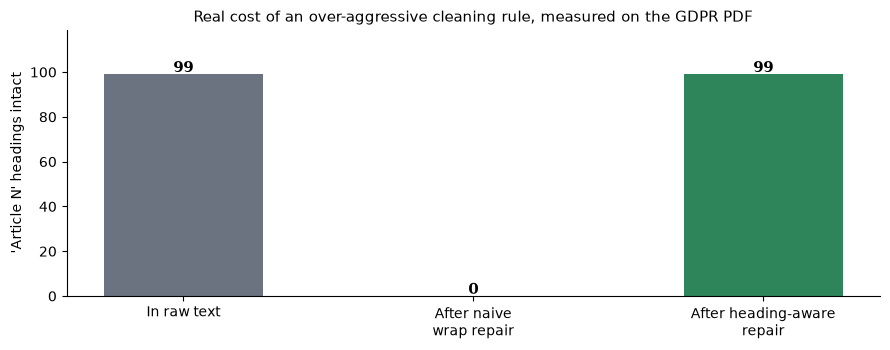

In [10]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(9, 3.6))

    labels = ["In raw text", "After naive\nwrap repair", "After heading-aware\nrepair"]
    values = [len(suspicious_joins), naive_survivors, safe_survivors]
    colours = ["#6b7280", "#c53030", "#2f855a"]

    bars = axis.bar(labels, values, color=colours, width=0.55)

    # Label each bar with its real count.
    for bar, value in zip(bars, values):
        axis.text(bar.get_x() + bar.get_width() / 2, value + 1, str(value),
                   ha="center", fontsize=11, fontweight="bold")

    axis.set_ylabel("'Article N' headings intact")
    axis.set_title(
        "Real cost of an over-aggressive cleaning rule, measured on the GDPR PDF",
        fontsize=11,
    )
    axis.set_ylim(0, max(values) * 1.2)
    axis.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

**Red is real content destroyed by a rule that looked reasonable.** This is the single most
important habit in this module: after writing any cleaning rule, count what it removed and
check that all of it was actually noise.

# 4. Header and footer removal, from evidence

**The intuition before the code.** A header is not identified by *what it says* — it is
identified by the fact that **the same line appears on almost every page**. That is a
measurable property, so detect it from the real document rather than hardcoding a string.

```mermaid
flowchart TD
    A["Collect first/last N lines\nof every page"] --> B["Count how often each\nexact line repeats"]
    B --> C{"Appears on > 50%\nof pages?"}
    C -->|"yes"| D["Page furniture - remove"]
    C -->|"no"| E["Real content - keep"]
```

![Diagram](diagrams/cell20-ff2315db94.svg)



In [11]:
# Define a function that detects repeated page furniture from real evidence.
def detect_page_furniture(page_texts, edge_lines=3, threshold=0.5):

    # Count how many distinct pages each candidate line appears on.
    line_page_counts = Counter()

    for page_text in page_texts:
        lines = [l.strip() for l in page_text.split("\n") if l.strip()]

        # Only the first and last few lines can be headers or footers.
        candidates = set(lines[:edge_lines] + lines[-edge_lines:])

        for line in candidates:
            line_page_counts[line] += 1

    # A line appearing on more than `threshold` of pages is furniture, not content.
    page_count = len(page_texts)
    furniture = {
        line: count for line, count in line_page_counts.items()
        if count / page_count > threshold
    }

    return furniture, line_page_counts


# Only run if PyMuPDF is available.
if pymupdf is not None:

    furniture, all_counts = detect_page_furniture(all_page_texts)

    print(f"Detected page furniture across {len(all_page_texts)} real pages "
          f"(appearing on >50% of them):\n")
    for line, count in sorted(furniture.items(), key=lambda kv: -kv[1]):
        print(f"  {count:3d}/{len(all_page_texts)} pages  {line[:70]!r}")

    if not furniture:
        print("  (none found at this threshold)")

    # Show the near-misses too - lines that repeat a lot but not enough to qualify.
    print(f"\nNear-misses (repeat on 10-50% of pages, deliberately NOT removed):\n")
    near = [(l, c) for l, c in all_counts.items()
            if 0.10 < c / len(all_page_texts) <= 0.50]
    for line, count in sorted(near, key=lambda kv: -kv[1])[:6]:
        print(f"  {count:3d}/{len(all_page_texts)} pages  {line[:70]!r}")

Detected page furniture across 88 real pages (appearing on >50% of them):

   81/88 pages  'EN'
   75/88 pages  'Official Journal of the European Union'

Near-misses (repeat on 10-50% of pages, deliberately NOT removed):

   11/88 pages  '2.'


The near-misses are the interesting part. Lowering the threshold to catch them would start
removing real content that merely happens to recur — the same over-cleaning trap as section 3,
in a different disguise.

# 5. Whitespace, and the correct order of operations

**The intuition before the code.** Whitespace collapse must come **last**. It is the most
destructive step because it erases the line structure every earlier rule depends on: once
newlines are collapsed to spaces, you can no longer tell a wrapped line from a paragraph
break, or find a header at the top of a page.

```mermaid
flowchart LR
    A["1. Unicode NFC"] --> B["2. De-hyphenate\n(needs trailing '-')"]
    B --> C["3. Wrap repair\n(needs line structure)"]
    C --> D["4. Remove furniture\n(needs page edges)"]
    D --> E["5. Collapse whitespace\n(destroys all of the above)"]
    E --> F["Cleaned text"]
```

![Diagram](diagrams/cell22-efec2d1ee9.svg)



In [12]:
# Define the full cleaning pipeline in the correct, dependency-respecting order.
def clean_page(page_text, furniture_lines, heading_patterns=None):

    # STEP 1 - Unicode normalization. NFC, not NFKC, to avoid lossy folding.
    text = unicodedata.normalize("NFC", page_text)

    # STEP 2 - remove detected page furniture, BEFORE line structure is destroyed.
    kept_lines = [
        line for line in text.split("\n")
        if line.strip() not in furniture_lines
    ]
    text = "\n".join(kept_lines)

    # STEP 3 + 4 - de-hyphenate and repair wraps, protecting real headings.
    text = repair_line_breaks_safe(text, heading_patterns)

    # STEP 5 - collapse whitespace LAST, once nothing else needs the structure.
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Clean one real page end to end and measure the change.
    cleaned_page = clean_page(raw_page_text, set(furniture.keys()))

    print(f"  Raw page length     : {len(raw_page_text):,} chars")
    print(f"  Cleaned page length : {len(cleaned_page):,} chars")
    print(f"  Removed             : {len(raw_page_text) - len(cleaned_page):,} chars "
          f"({(len(raw_page_text) - len(cleaned_page))/len(raw_page_text):.1%})\n")

    print("First 400 characters of the cleaned real page:\n")
    print(cleaned_page[:400])

  Raw page length     : 4,079 chars
  Cleaned page length : 3,974 chars
  Removed             : 105 chars (2.6%)

First 400 characters of the cleaned real page:

(f) where applicable, that the controller intends to transfer personal data to a recipient in a third country or internat­ ional organisation and the existence or absence of an adequacy decision by the Commission, or in the case of transfers referred to in Article 46 or 47, or the second subparagraph of Article 49(1), reference to the appropriate or suitable safeguards and the means to obtain a co


# 6. End-to-end: one real document, fully cleaned

Fetch, detect furniture from the real pages, clean every page in the correct order, and
measure exactly what was removed — one real document, one unbroken run.

In [13]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # STEP 1 - fetch the real source document.
    end_to_end_path = fetch("gdpr_pdf", quiet=True)

    # STEP 2 - extract every real page.
    document = pymupdf.open(end_to_end_path)
    end_to_end_pages = [document.load_page(i).get_text("text") for i in range(len(document))]
    document.close()

    # STEP 3 - detect page furniture from the real document's own repetition.
    end_to_end_furniture, _ = detect_page_furniture(end_to_end_pages)

    # STEP 4 - clean every page in the correct order.
    end_to_end_cleaned = [
        clean_page(page, set(end_to_end_furniture.keys()))
        for page in end_to_end_pages
    ]

    # STEP 5 - measure exactly what the pipeline removed.
    raw_chars = sum(len(p) for p in end_to_end_pages)
    clean_chars = sum(len(p) for p in end_to_end_cleaned)

    # Verify no page was emptied entirely - that would signal a rule gone wrong.
    emptied = sum(1 for p in end_to_end_cleaned if not p.strip())

    print(f"  Pages processed        : {len(end_to_end_pages)}")
    print(f"  Furniture lines removed: {len(end_to_end_furniture)}")
    print(f"  Characters before      : {raw_chars:,}")
    print(f"  Characters after       : {clean_chars:,}")
    print(f"  Removed                : {raw_chars - clean_chars:,} "
          f"({(raw_chars - clean_chars)/raw_chars:.1%})")
    print(f"  Pages emptied entirely : {emptied}  (must be 0)\n")

    # Verify real headings survived the whole pipeline.
    surviving_headings = sum(
        1 for page in end_to_end_cleaned for line in page.split("\n")
        if re.fullmatch(r"Article\s+\d+", line.strip())
    )
    print(f"  'Article N' headings intact after full pipeline : {surviving_headings}")

  Pages processed        : 88
  Furniture lines removed: 2
  Characters before      : 360,853
  Characters after       : 352,027
  Removed                : 8,826 (2.4%)
  Pages emptied entirely : 0  (must be 0)

  'Article N' headings intact after full pipeline : 99


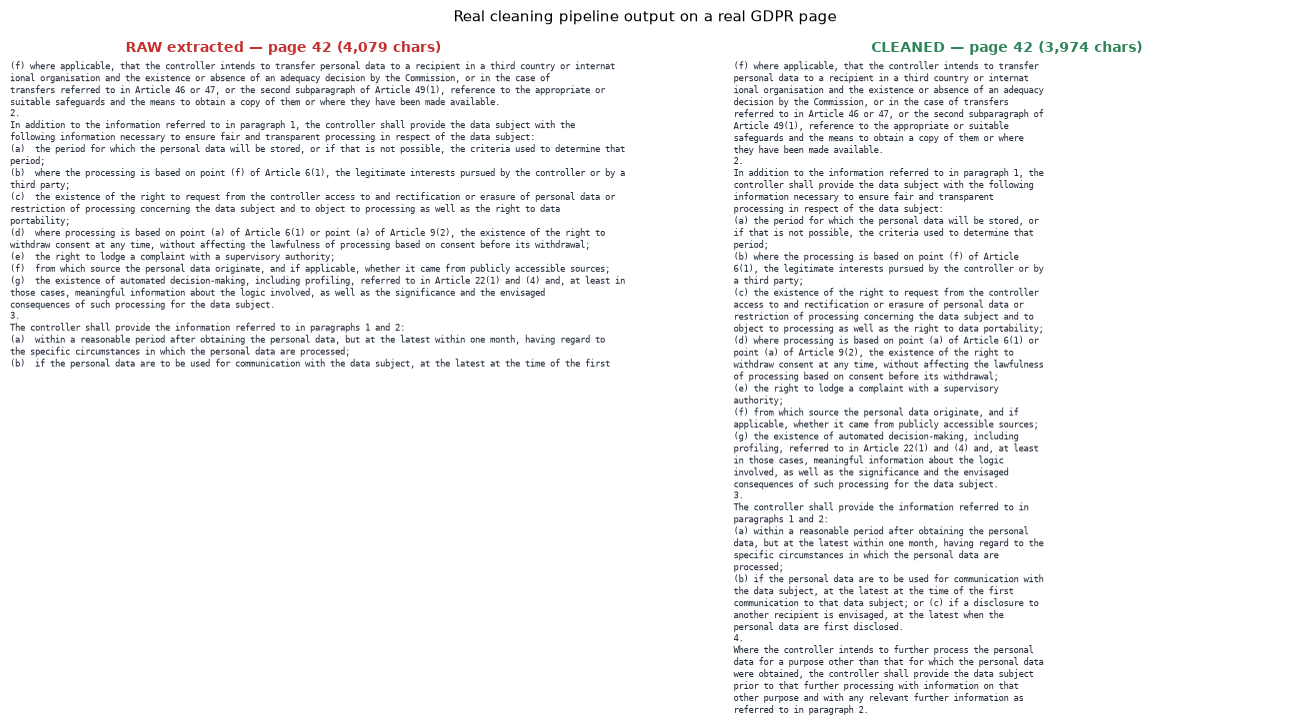

In [14]:
# Render the before/after of real pages as an image, not just printed numbers.
if pymupdf is not None:

    import matplotlib.pyplot as plt
    import textwrap

    # Pick one real page with plenty of text to show the transformation.
    comparison_index = 41
    before_text = end_to_end_pages[comparison_index]
    after_text = end_to_end_cleaned[comparison_index]

    figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(13, 7))

    # LEFT - the real raw extracted text, line breaks preserved exactly.
    left_axis.axis("off")
    left_axis.set_title(f"RAW extracted — page {comparison_index + 1} "
                         f"({len(before_text):,} chars)",
                         fontsize=10, fontweight="bold", color="#c53030")
    left_axis.text(0.0, 1.0, "\n".join(before_text.split("\n")[:26]),
                    fontsize=6.5, family="monospace", va="top", color="#1f2937")

    # RIGHT - the real cleaned text.
    right_axis.axis("off")
    right_axis.set_title(f"CLEANED — page {comparison_index + 1} "
                          f"({len(after_text):,} chars)",
                          fontsize=10, fontweight="bold", color="#2f855a")
    wrapped_after = "\n".join(
        textwrap.fill(line, width=62) for line in after_text.split("\n")[:16]
    )
    right_axis.text(0.0, 1.0, wrapped_after, fontsize=6.5, family="monospace",
                     va="top", color="#1f2937")

    plt.suptitle("Real cleaning pipeline output on a real GDPR page", fontsize=11)
    plt.tight_layout()
    plt.show()

# 7. Module summary

## Key points

1. **Look at the real text before writing any rule.** Every rule in this module exists because
   the real document demanded it.
2. **Order matters and is dependency-driven**: Unicode, then de-hyphenate, then wrap repair,
   then furniture removal, then whitespace collapse last. Each step destroys evidence the
   later ones no longer need — and that the earlier ones did.
3. **NFC by default, NFKC only deliberately.** NFKC folding `²` to `2` is a content change.
4. **Detect page furniture from repetition**, not from hardcoded strings. It is a measurable
   property of the real document.
5. **Every cleaning rule is a bet.** After writing one, count what it removed and verify all of
   it was noise. The naive wrap-repair rule silently destroyed every `Article N` heading.
6. **The fix for an over-aggressive rule is an exception, not abandonment.** Protect the
   patterns you can identify; keep the benefit for everything else.

## Interview answer: "How do you clean extracted PDF text?"

> In a fixed order, because the steps depend on each other. Unicode NFC first so comparisons
> work at all. Then de-hyphenation, which needs the trailing hyphen still present. Then
> line-wrap repair, which needs line structure. Then header and footer removal, which I detect
> by finding lines that repeat across more than half the pages rather than hardcoding strings.
> Whitespace collapse comes last because it destroys the structure everything else relies on.
> The critical part is measuring afterwards: I count what each rule removed and check it was
> all noise. On the GDPR PDF, a naive wrap-repair rule silently merged every article heading
> into its body text, which only showed up because I counted surviving headings.

## Exercises

1. **Tune the furniture threshold.** Sweep it from 0.1 to 0.9 and plot how many lines are
   classified as furniture. Where does it start removing real content?
2. **A better heading detector.** Replace the regex list with the font-size and weight approach
   from [module 2b](../2b.%20PDF%20parsing/), and compare which protects more real headings.
3. **Measure the embedding impact.** Embed the same page raw and cleaned, and compute the
   cosine similarity between them. How much did cleaning actually move the vector?
4. **A destructive-rule detector.** Write a function that takes any cleaning function, applies
   it to a document, and reports every line that was deleted entirely — so a reviewer can scan
   for false positives.

## Next: [Module 2h — Deduplication & Versioning](../2h.%20Deduplication%20and%20versioning/)

Clean text still contains the same paragraph three times, from three near-identical documents.
Next: detecting exact and near duplicates, and deciding which version wins.